In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Loading and Exploration

In [2]:
# Load the datasets
train_df = pd.read_csv('car_crash_train.csv')
test_df = pd.read_csv('car_crash_test.csv')

print("Training Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("\nFirst few rows of training data:")
print(train_df.head())
print("\nData Info:")
print(train_df.info())
print("\nTarget Variable Distribution:")
print(train_df['Severity'].value_counts())

Training Data Shape: (4000, 19)
Test Data Shape: (1000, 19)

First few rows of training data:
   Crash Speed (km/h)  Impact Angle (degrees) Airbag Deployed Seatbelt Used  \
0                 182                      69             Yes            No   
1                 192                      73             Yes            No   
2                 114                      77              No           Yes   
3                  93                      14              No           Yes   
4                 170                      96              No           Yes   

  Weather Conditions Road Conditions   Crash Type Vehicle Type  \
0              Clear             Dry     Rollover        Sedan   
1              Clear             Dry      Head-on        Truck   
2              Clear             Dry      Head-on        Sedan   
3              Clear             Dry     Rear-end        Truck   
4              Clear             Dry  Side impact          SUV   

   Vehicle Age (years) Brake Condi

In [3]:
# Statistical Summary
print("\nBasic Statistics:")
print(train_df.describe())

print("\nMissing Values in Training Data:")
print(train_df.isnull().sum())

print("\nMissing Values in Test Data:")
print(test_df.isnull().sum())


Basic Statistics:
       Crash Speed (km/h)  Impact Angle (degrees)  Vehicle Age (years)  \
count         4000.000000             4000.000000          4000.000000   
mean           110.999750               89.979750             9.445500   
std             52.227839               51.301514             5.718147   
min             20.000000                0.000000             0.000000   
25%             66.000000               45.000000             5.000000   
50%            112.000000               89.500000             9.000000   
75%            157.000000              134.000000            14.000000   
max            199.000000              179.000000            19.000000   

        Driver Age  Driver Experience (years)  Alcohol Level (BAC%)  \
count  4000.000000                4000.000000           4000.000000   
mean     48.698750                  24.723000              0.101216   
std      17.815972                  14.211818              0.057820   
min      18.000000            

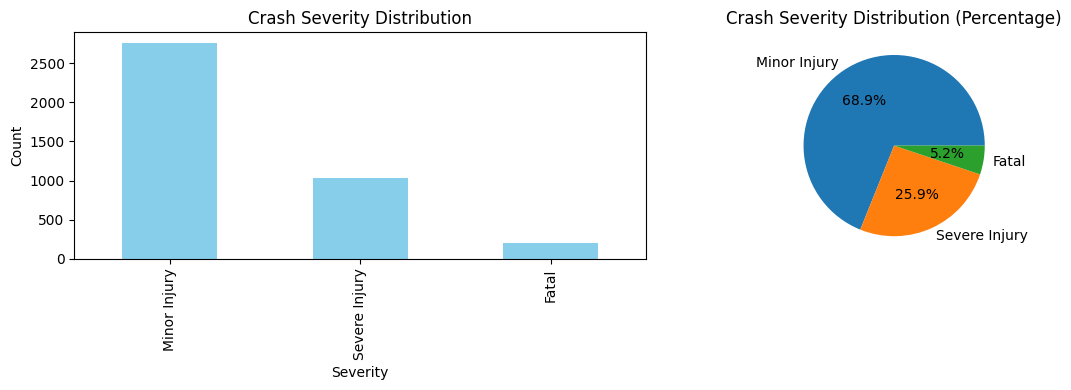


Percentage Distribution:
Severity
Minor Injury     68.90
Severe Injury    25.95
Fatal             5.15
Name: proportion, dtype: float64


In [4]:
# Visualization: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
train_df['Severity'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Crash Severity Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

# Pie chart
train_df['Severity'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Crash Severity Distribution (Percentage)')

plt.tight_layout()
plt.show()

print("\nPercentage Distribution:")
print(train_df['Severity'].value_counts(normalize=True) * 100)

## 2. Data Preprocessing

In [5]:
# Identify categorical and numerical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Remove target variable from categorical columns
target_col = 'Severity'
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

Categorical Columns: ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Severity']
Numerical Columns: ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']


In [6]:
# Separate features and target for training data
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

# Prepare test data (remove target if present)
X_test = test_df.drop(columns=[target_col], errors='ignore')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    label_encoders[col] = le
    
    # Apply same encoding to test data
    X_test[col] = le.transform(X_test[col])

# Encode target variable
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)

print("\nTarget Classes:", le_target.classes_)
print("Encoded Target Values:", np.unique(y_train_encoded))

X_train shape: (4000, 18)
y_train shape: (4000,)
X_test shape: (1000, 18)

Target Classes: ['Fatal' 'Minor Injury' 'Severe Injury']
Encoded Target Values: [0 1 2]


In [7]:
# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features shape after scaling:", X_train_scaled.shape)
print("Scaled data mean (should be close to 0):", X_train_scaled.mean(axis=0)[:5])
print("Scaled data std (should be close to 1):", X_train_scaled.std(axis=0)[:5])

Features shape after scaling: (4000, 18)
Scaled data mean (should be close to 0): [-1.11910481e-16  8.61533067e-17 -3.68594044e-17 -3.37507799e-17
  3.37507799e-17]
Scaled data std (should be close to 1): [1. 1. 1. 1. 1.]


## 3. Model Training and Evaluation

We'll train multiple classification models and compare their performance:

In [8]:
# Imports
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_scaled,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

print(f"Training set size: {X_train_split.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# Oversampling helper to balance training classes

def oversample_minority(X, y):
    classes, counts = np.unique(y, return_counts=True)
    max_count = counts.max()
    X_resampled = []
    y_resampled = []
    for cls, count in zip(classes, counts):
        X_cls = X[y == cls]
        y_cls = y[y == cls]
        reps = max_count // count
        rem = max_count % count
        X_resampled.append(np.vstack([X_cls] * reps + ([X_cls[:rem]] if rem else [])))
        y_resampled.append(np.concatenate([y_cls] * reps + ([y_cls[:rem]] if rem else [])))
    return np.vstack(X_resampled), np.concatenate(y_resampled)

X_train_balanced, y_train_balanced = oversample_minority(X_train_split, y_train_split)
print("Balanced training set shape:", X_train_balanced.shape)
print("Balanced class counts:", np.bincount(y_train_balanced))

# Hyperparameter tuning helper
def tune_model(model, param_dist, X, y, name, n_iter=5):
    print("\n" + "="*50)
    print(f"TUNING {name}")
    print("="*50)
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='f1_macro',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X, y)
    print("Best params:", search.best_params_)
    return search.best_estimator_

# Dictionary to store models and performance
models = {}
results = {}

Training set size: 3200
Validation set size: 800
Balanced training set shape: (6615, 18)
Balanced class counts: [2205 2205 2205]


In [9]:
# 1. Logistic Regression
print("\n" + "="*50)
print("1. LOGISTIC REGRESSION")
print("="*50)

lr_model = tune_model(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    {'C': [0.01, 0.1, 1, 10, 100]},
    X_train_balanced,
    y_train_balanced,
    'LOGISTIC REGRESSION',
    n_iter=5
)
lr_model.fit(X_train_balanced, y_train_balanced)

y_pred_lr = lr_model.predict(X_val)

lr_accuracy = accuracy_score(y_val, y_pred_lr)
lr_precision = precision_score(y_val, y_pred_lr, average='weighted')
lr_recall = recall_score(y_val, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_val, y_pred_lr, average='weighted')

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

models['Logistic Regression'] = lr_model
results['Logistic Regression'] = lr_accuracy


1. LOGISTIC REGRESSION

TUNING LOGISTIC REGRESSION
Best params: {'C': 0.01}
Accuracy: 0.3137
Precision: 0.5447
Recall: 0.3137
F1-Score: 0.3691


In [10]:
# 2. Gaussian Naive Bayes
print("\n" + "="*50)
print("2. GAUSSIAN NAIVE BAYES")
print("="*50)
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)
y_pred_nb = nb_model.predict(X_val)

nb_accuracy = accuracy_score(y_val, y_pred_nb)
nb_precision = precision_score(y_val, y_pred_nb, average='weighted')
nb_recall = recall_score(y_val, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_val, y_pred_nb, average='weighted')

print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")

models['Gaussian Naive Bayes'] = nb_model
results['Gaussian Naive Bayes'] = nb_accuracy


2. GAUSSIAN NAIVE BAYES
Accuracy: 0.3375
Precision: 0.5497
Recall: 0.3375
F1-Score: 0.3950


In [11]:
# 3. Random Forest Classifier
print("\n" + "="*50)
print("3. RANDOM FOREST CLASSIFIER")
print("="*50)
rf_model = tune_model(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    {
        'n_estimators': [100, 150, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    X_train_balanced,
    y_train_balanced,
    'RANDOM FOREST',
    n_iter=6
)
rf_model.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf, average='weighted')
rf_recall = recall_score(y_val, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_val, y_pred_rf, average='weighted')

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

models['Random Forest'] = rf_model
results['Random Forest'] = rf_accuracy


3. RANDOM FOREST CLASSIFIER

TUNING RANDOM FOREST
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Accuracy: 0.6750
Precision: 0.5274
Recall: 0.6750
F1-Score: 0.5635


In [12]:
# 4. Gradient Boosting Classifier
print("\n" + "="*50)
print("4. GRADIENT BOOSTING CLASSIFIER")
print("="*50)
gb_model = tune_model(
    GradientBoostingClassifier(random_state=42),
    {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    X_train_balanced,
    y_train_balanced,
    'GRADIENT BOOSTING',
    n_iter=4
)
gb_model.fit(X_train_balanced, y_train_balanced)
y_pred_gb = gb_model.predict(X_val)

gb_accuracy = accuracy_score(y_val, y_pred_gb)
gb_precision = precision_score(y_val, y_pred_gb, average='weighted')
gb_recall = recall_score(y_val, y_pred_gb, average='weighted')
gb_f1 = f1_score(y_val, y_pred_gb, average='weighted')

print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")
print(f"F1-Score: {gb_f1:.4f}")

models['Gradient Boosting'] = gb_model
results['Gradient Boosting'] = gb_accuracy


4. GRADIENT BOOSTING CLASSIFIER

TUNING GRADIENT BOOSTING
Best params: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1}
Accuracy: 0.5837
Precision: 0.5547
Recall: 0.5837
F1-Score: 0.5674


In [13]:
# 5. K-Nearest Neighbors Classifier
print("\n" + "="*50)
print("5. K-NEAREST NEIGHBORS CLASSIFIER")
print("="*50)
knn_model = tune_model(
    KNeighborsClassifier(),
    {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    },
    X_train_balanced,
    y_train_balanced,
    'K-NEAREST NEIGHBORS',
    n_iter=4
)
knn_model.fit(X_train_balanced, y_train_balanced)
y_pred_knn = knn_model.predict(X_val)

knn_accuracy = accuracy_score(y_val, y_pred_knn)
knn_precision = precision_score(y_val, y_pred_knn, average='weighted')
knn_recall = recall_score(y_val, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_val, y_pred_knn, average='weighted')

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1:.4f}")

models['K-Nearest Neighbors'] = knn_model
results['K-Nearest Neighbors'] = knn_accuracy


5. K-NEAREST NEIGHBORS CLASSIFIER

TUNING K-NEAREST NEIGHBORS
Best params: {'weights': 'distance', 'n_neighbors': 3}
Accuracy: 0.4412
Precision: 0.5500
Recall: 0.4412
F1-Score: 0.4716


In [14]:
# 6. Decision Tree Classifier
print("\n" + "="*50)
print("6. DECISION TREE CLASSIFIER")
print("="*50)
dt_model = tune_model(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    X_train_balanced,
    y_train_balanced,
    'DECISION TREE',
    n_iter=6
)
dt_model.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt_model.predict(X_val)

dt_accuracy = accuracy_score(y_val, y_pred_dt)
dt_precision = precision_score(y_val, y_pred_dt, average='weighted')
dt_recall = recall_score(y_val, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_val, y_pred_dt, average='weighted')

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

models['Decision Tree'] = dt_model
results['Decision Tree'] = dt_accuracy


6. DECISION TREE CLASSIFIER

TUNING DECISION TREE
Best params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Accuracy: 0.5713
Precision: 0.5771
Recall: 0.5713
F1-Score: 0.5740



MODEL COMPARISON
                  Model  Accuracy  Weighted F1  Macro F1
5         Decision Tree   0.57125     0.574021  0.369100
3     Gradient Boosting   0.58375     0.567394  0.356481
4   K-Nearest Neighbors   0.44125     0.471648  0.310260
1  Gaussian Naive Bayes   0.33750     0.394964  0.280357
2         Random Forest   0.67500     0.563472  0.280016
0   Logistic Regression   0.31375     0.369050  0.265410


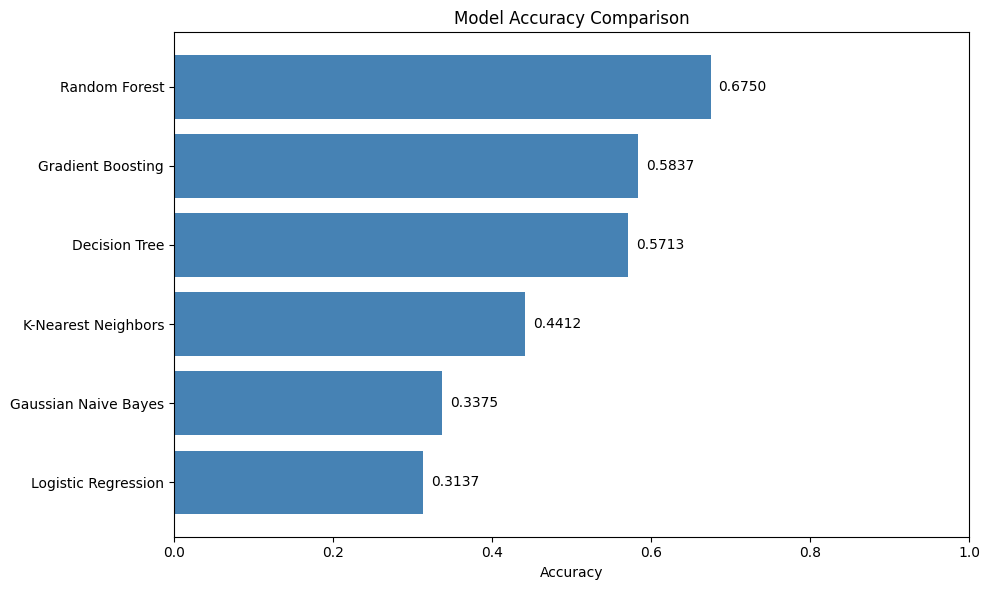

In [15]:
# Model Comparison
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

metrics = []
for model_name, model in models.items():
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    weighted_f1 = f1_score(y_val, y_pred, average='weighted')
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    metrics.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Weighted F1': weighted_f1,
        'Macro F1': macro_f1
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df.sort_values(['Macro F1', 'Accuracy'], ascending=False))

# Visualize Model Accuracy
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
results_df_sorted = results_df.sort_values('Accuracy', ascending=True)
ax.barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='steelblue')
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xlim([0, 1])
for i, v in enumerate(results_df_sorted['Accuracy']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()




CROSS-VALIDATED MODEL SELECTION
                  Model  CV Accuracy  CV Macro F1
5         Decision Tree     0.539687     0.331905
4   K-Nearest Neighbors     0.582812     0.319624
3     Gradient Boosting     0.653438     0.298963
1  Gaussian Naive Bayes     0.689063     0.271970
2         Random Forest     0.689063     0.271970
0   Logistic Regression     0.276250     0.232019

DETAILED EVALUATION - Decision Tree

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.07      0.10      0.08        41
 Minor Injury       0.71      0.71      0.71       551
Severe Injury       0.32      0.31      0.32       208

     accuracy                           0.57       800
    macro avg       0.37      0.37      0.37       800
 weighted avg       0.58      0.57      0.57       800


Confusion Matrix:
[[  4  29   8]
 [ 37 389 125]
 [ 14 130  64]]


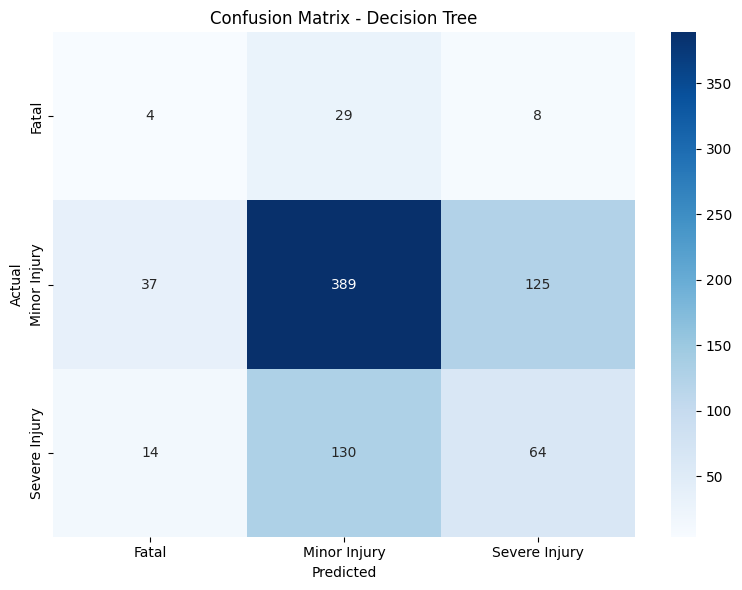

In [16]:
# Detailed Evaluation of Best Model
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

print("\n" + "="*50)
print("CROSS-VALIDATED MODEL SELECTION")
print("="*50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for model_name, model in models.items():
    cv_accuracy_scores = cross_val_score(model, X_train_split, y_train_split, scoring='accuracy', cv=cv, n_jobs=-1)
    cv_macro_f1_scores = cross_val_score(model, X_train_split, y_train_split, scoring='f1_macro', cv=cv, n_jobs=-1)
    cv_results.append({
        'Model': model_name,
        'CV Accuracy': np.mean(cv_accuracy_scores),
        'CV Macro F1': np.mean(cv_macro_f1_scores)
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV Macro F1', ascending=False)
print(cv_df)

best_model_name = cv_df.iloc[0]['Model']
best_model = clone(models[best_model_name])
best_model.fit(X_train_balanced, y_train_balanced)
best_accuracy = float(cv_df.iloc[0]['CV Accuracy'])
best_macro_f1 = float(cv_df.iloc[0]['CV Macro F1'])

print("\n" + "="*50)
print(f"DETAILED EVALUATION - {best_model_name}")
print("="*50)

# Re-evaluate on the held-out validation set for a final check
y_pred_best = best_model.predict(X_val)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_best, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

In [17]:
# Confirm Best Model Selection
print("\n" + "="*50)
print("BEST MODEL CONFIRMATION")
print("="*50)
print(f"Best Model selected: {best_model_name}")
print(f"Cross-Validation Accuracy: {best_accuracy:.4f}")
print(f"Cross-Validation Macro F1: {best_macro_f1:.4f}")

# Calculate actual validation set accuracy
val_accuracy = accuracy_score(y_val, y_pred_best)
val_macro_f1 = f1_score(y_val, y_pred_best, average='macro')
print(f"\nActual Validation Set Accuracy: {val_accuracy:.4f}")
print(f"Actual Validation Set Macro F1: {val_macro_f1:.4f}")


BEST MODEL CONFIRMATION
Best Model selected: Decision Tree
Cross-Validation Accuracy: 0.5397
Cross-Validation Macro F1: 0.3319

Actual Validation Set Accuracy: 0.5713
Actual Validation Set Macro F1: 0.3691



FEATURE IMPORTANCE

Top 15 Most Important Features:
                      Feature  Importance
13       Alcohol Level (BAC%)    0.137236
17    Visibility Distance (m)    0.133151
12  Driver Experience (years)    0.116102
0          Crash Speed (km/h)    0.109070
1      Impact Angle (degrees)    0.108678
11                 Driver Age    0.101181
8         Vehicle Age (years)    0.078151
6                  Crash Type    0.032194
16            Traffic Density    0.026872
7                Vehicle Type    0.025249
14          Distraction Level    0.022687
15                Time of Day    0.018560
4          Weather Conditions    0.018255
5             Road Conditions    0.017493
9             Brake Condition    0.016958


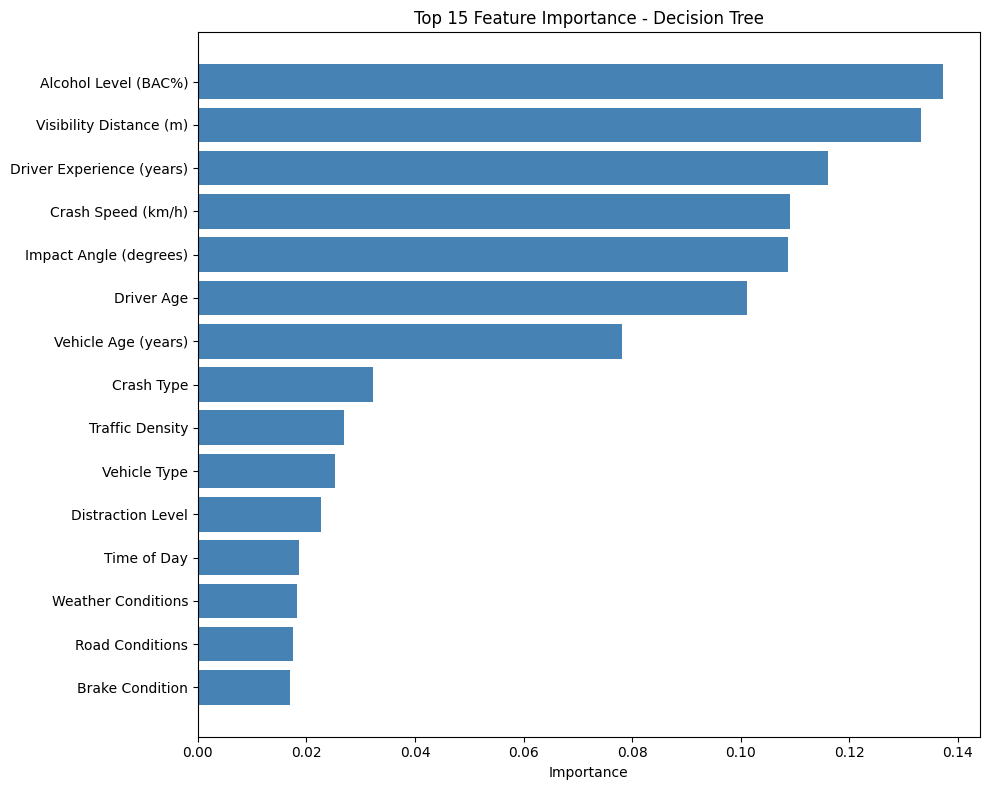

In [18]:
# Feature Importance (if available in the model)
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*50)
    print("FEATURE IMPORTANCE")
    print("="*50)
    
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15))
    
    # Visualize Feature Importance
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance.head(15)
    ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 15 Feature Importance - {best_model_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 4. Making Predictions on Test Data

In [19]:
# Train best model on full training data
print("Training best model on full training data...")
best_model.fit(X_train_scaled, y_train_encoded)

# Make predictions on test data
print("Making predictions on test data...")
y_test_pred_encoded = best_model.predict(X_test_scaled)

# Decode predictions back to original labels
y_test_pred = le_target.inverse_transform(y_test_pred_encoded)

print("Predictions made successfully!")
print(f"Number of predictions: {len(y_test_pred)}")
print("\nPrediction distribution:")
print(pd.Series(y_test_pred).value_counts())
print("\nFirst 10 predictions:")
print(y_test_pred[:10])

Training best model on full training data...
Making predictions on test data...
Predictions made successfully!
Number of predictions: 1000

Prediction distribution:
Minor Injury     696
Severe Injury    250
Fatal             54
Name: count, dtype: int64

First 10 predictions:
['Fatal' 'Minor Injury' 'Minor Injury' 'Minor Injury' 'Minor Injury'
 'Minor Injury' 'Minor Injury' 'Severe Injury' 'Fatal' 'Minor Injury']


## 5. Project Summary and Insights

In [20]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("\n1. DATASET INFORMATION")
print(f"   - Training samples: {train_df.shape[0]}")
print(f"   - Test samples: {test_df.shape[0]}")
print(f"   - Total features: {len(X_train.columns)}")
print(f"   - Categorical features: {len(categorical_cols)}")
print(f"   - Numerical features: {len(numerical_cols)}")

print("\n2. TARGET VARIABLE DISTRIBUTION")
for severity, count in train_df['Severity'].value_counts().items():
    percentage = (count / len(train_df)) * 100
    print(f"   - {severity}: {count} ({percentage:.2f}%)")

print("\n3. MODELS TRAINED AND EVALUATED")
print("   " + "\n   ".join([f"- {model}: {accuracy:.4f}" for model, accuracy in results.items()]))

print(f"\n4. BEST MODEL: {best_model_name} (selected by cross-validated Macro F1)")
print(f"   - Cross-Validation Accuracy: {best_accuracy:.4f}")
print(f"   - Validation Set Accuracy: {val_accuracy:.4f}")
print(f"   - Cross-Validation Macro F1: {best_macro_f1:.4f}")
print(f"   - Validation Set Macro F1: {val_macro_f1:.4f}")

print("\n5. KEY IMPROVEMENTS APPLIED")
print("   - Balanced training data via resampling for better class coverage")
print("   - Hyperparameter tuning for Logistic Regression, Random Forest, Gradient Boosting, KNN, and Decision Tree")
print("   - Selection based on Macro F1 to ensure fair performance across all severity classes")

PROJECT SUMMARY

1. DATASET INFORMATION
   - Training samples: 4000
   - Test samples: 1000
   - Total features: 18
   - Categorical features: 11
   - Numerical features: 7

2. TARGET VARIABLE DISTRIBUTION
   - Minor Injury: 2756 (68.90%)
   - Severe Injury: 1038 (25.95%)
   - Fatal: 206 (5.15%)

3. MODELS TRAINED AND EVALUATED
   - Logistic Regression: 0.3137
   - Gaussian Naive Bayes: 0.3375
   - Random Forest: 0.6750
   - Gradient Boosting: 0.5837
   - K-Nearest Neighbors: 0.4412
   - Decision Tree: 0.5713

4. BEST MODEL: Decision Tree (selected by cross-validated Macro F1)
   - Cross-Validation Accuracy: 0.5397
   - Validation Set Accuracy: 0.5713
   - Cross-Validation Macro F1: 0.3319
   - Validation Set Macro F1: 0.3691

5. KEY IMPROVEMENTS APPLIED
   - Balanced training data via resampling for better class coverage
   - Hyperparameter tuning for Logistic Regression, Random Forest, Gradient Boosting, KNN, and Decision Tree
   - Selection based on Macro F1 to ensure fair performan

## 7. Model Interpretation

### Why the Final Model is Chosen by Macro F1

This notebook now evaluates models with balanced training and selects the best candidate based on **Macro F1** rather than raw accuracy.

#### Improvements made:
- Resampled the training data to reduce class imbalance and improve minority-class learning.
- Applied hyperparameter tuning for Logistic Regression, Random Forest, Gradient Boosting, KNN, and Decision Tree.
- Used cross-validation and Macro F1 scoring for robust selection.

#### Why this is better?
- The target classes are imbalanced, so accuracy can overstate performance on the majority class.
- Macro F1 assigns equal weight to each class, making the model evaluation fairer for Fatal and Severe Injury predictions.
- Balanced training helps the model pay attention to underrepresented severity levels.

#### What does this mean for the final model?
- The selected model is the one that best balances precision and recall across all severity categories.
- This improves real-world reliability when predicting crash severity for rare but critical classes.
